MOVING AVERAGE STRATEGY ON MICROSOFT STOCKS

In [ ]:
#import libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

In [ ]:
#data import and data munging
mic=pd.read_csv("microsoft.csv")
mic["Date"]=pd.to_datetime(mic["Date"])
mic.set_index("Date",inplace=True)
mic.sort_index(inplace=True)
mic.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2014-12-31,46.730000,47.439999,46.450001,46.450001,42.848763,21552500
2015-01-02,46.660000,47.419998,46.540001,46.759998,43.134731,27913900
2015-01-05,46.369999,46.730000,46.250000,46.330002,42.738068,39673900
2015-01-06,46.380001,46.750000,45.540001,45.650002,42.110783,36447900
2015-01-07,45.980000,46.459999,45.490002,46.230000,42.645817,29114100


In [ ]:
#Calibrate on years 2015-2017
ms=mic["2014-12-31":"2017-12-31"].dropna()
print("="*10+"head of the dataframe"+"="*10)
print(ms.head(3))
print("")
print("="*10+"tail of the dataframe"+"="*10)
print(ms.tail(3))

==========head of the dataframe==========
                 Open       High        Low      Close  Adj Close    Volume
Date                                                                       
2014-12-31  46.730000  47.439999  46.450001  46.450001  42.848763  21552500
2015-01-02  46.660000  47.419998  46.540001  46.759998  43.134731  27913900
2015-01-05  46.369999  46.730000  46.250000  46.330002  42.738068  39673900

==========tail of the dataframe==========
                 Open       High        Low      Close  Adj Close    Volume
Date                                                                       
2017-12-27  85.650002  85.980003  85.220001  85.709999  85.309265  14678000
2017-12-28  85.900002  85.930000  85.550003  85.720001  85.319214  10594300
2017-12-29  85.629997  86.050003  85.500000  85.540001  85.140060  18717400


In [ ]:
#determine means,shares,earn, profit, loses and wealth
ms["Close1"]=ms["Close"].shift(1).dropna()
ms["MA10"]=ms["Close"].rolling(10).mean()
ms["MA50"]=ms["Close"].rolling(50).mean()
ms["Shares"]=[1 if ms.loc[i,"MA10"]>ms.loc[i,"MA50"] else 0 
              for i in ms.index]
ms["earn"]=[ms.loc[i,"Close"]-ms.loc[i,"Close1"] if ms.loc[i,"Shares"]==1 else 0 
            for i in ms.index]

ms["profit"]=ms["earn"].where(ms["earn"]>0,0)
ms["loses"]=ms["earn"].where(ms["earn"]<0,0)

ms["wealth"]=ms["earn"].cumsum()
real_wealth=ms["wealth"].iloc[-1]
print(f"final wealth is {real_wealth:.2f} euro")

final wealth is 32.27 euro


In [ ]:
#Drawdown
ms["peak"]=ms["wealth"].cummax()
ms["drawdown"]=ms["wealth"]-ms["peak"]
max_drawdown=ms["drawdown"].min()
print(f"max drawdown is {max_drawdown:.2f} euro")

max drawdown is -7.69 euro


Com: My maximum drawdown is -7.69 euros, which is a drop of 23.8%.

In [ ]:
#Sharpe ratio with european central bank(ECB) rates 
ECB_rate=0.03 #3%
daily_ECB_rate=0.03/(252*3) # for three 03 years
ms["returns"]=np.log(ms["Close"]/ms["Close"].shift(1)).dropna()
mu=ms["returns"].mean()
volatility=ms["returns"].std()
sharpe_ratio=(mu-daily_ECB_rate)/volatility*np.sqrt(252*3)
print(f"sharpe ratio is {sharpe_ratio:.2f}")

sharpe ratio is 1.49


Com: sharpe ratio=1.49>1 , so my strategy is going well

#VISUALISATIONS: rolling means, profit and loses, my strategy vs benchmark

market volatility is 0.01


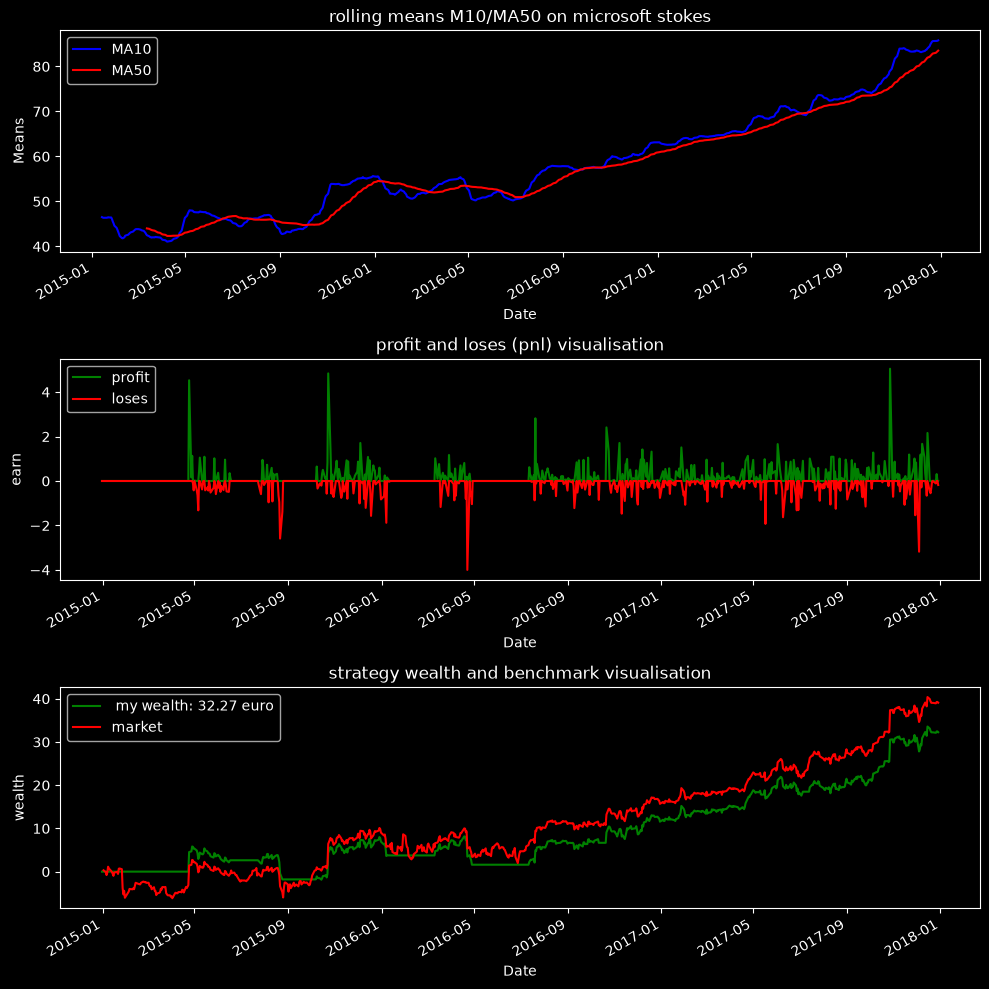

In [ ]:
# rolling means visualisation
plt.style.use("dark_background")
fig,(axe1, axe2, axe3)=plt.subplots(3,1, figsize=(10,10))
ms["MA10"].plot(ax=axe1,label="MA10", color="blue", alpha=1)
ms["MA50"].plot(ax=axe1, label="MA50", color="red", alpha=1)
axe1.set_ylabel("Means")
axe1.set_title("rolling means M10/MA50 on microsoft stokes")
axe1.legend(loc="best")

#profit and loses (pnl) visualisation
ms["profit"].plot(ax=axe2, label="profit", color="green", alpha=1)
ms["loses"].plot(ax=axe2, label="loses", color="red", alpha=1)
axe2.set_ylabel("earn")
axe2.set_title("profit and loses (pnl) visualisation")
axe2.legend(loc="best")

# wealth and benchmark visualisation
ms["bench_returns"]=np.log(ms["Close"]/ms["Close"].shift(1)).dropna()
bench_volatility=ms["bench_returns"].std()
print(f"market volatility is {bench_volatility:.2f}")
ms["Benchmark"]=ms["Close"].diff()
ms["benchmark"]=np.log(ms["Close"]/ms["Close"].shift(1)).dropna()
ms["Benchmark"]=ms["Benchmark"].cumsum()
ms["wealth"].plot(ax=axe3,label=f""" my wealth: {real_wealth:.2f} euro""", color="green", alpha=1)
ms["Benchmark"].plot(ax=axe3, label="market", color="red", alpha=1)
axe3.set_ylabel("wealth")
axe3.set_title("strategy wealth and benchmark visualisation")
axe3.legend(loc="best")

plt.tight_layout()
plt.show()

Conclusion:
The market outperforms my strategy with a volatility of 0.01. However, I hold up better during a downturn.